<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
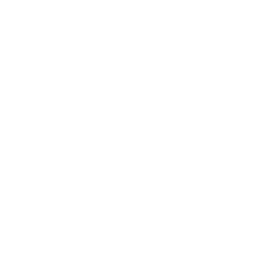
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">EWMA-Trendanalyse der Medikationsfehlerrate</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Gesundheitswesen / Patientensicherheit &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Diese Analyse überwacht die wöchentliche Medikationsfehlerrate auf einer Intensivstation (ITS) mithilfe einer **exponentiell gewichteten gleitenden Durchschnittskontrollkarte (EWMA)** aus PROC MACONTROL. Die Intensivstation hat in Woche 51 des Beobachtungsfensters ein neues elektronisches Medikationsverordnungssystem (eMAR) eingeführt. Patientensicherheitsteams benötigen eine Frühwarnmethode, die einen anhaltenden Anstieg der Fehler schnell erkennt, bevor sich ein Quartal an Schadensmeldungen anhäuft.

Die EWMA-Karte mit Glättungsgewicht **Lambda = 0,3** wird in zwei Phasen aufgebaut. Zunächst werden die Regelgrenzen aus der stabilen Basislinie vor der Migration (Wochen 1-50) ermittelt, danach wird die gesamte 100-Wochen-Reihe gegen diese fixen Grenzen überwacht. Die Karte bleibt während der gesamten Basislinie innerhalb der Kontrolle und signalisiert **in der ersten Woche nach der Einführung** einen außer Kontrolle geratenen Zustand, was bestätigt, dass der eMAR-Übergang mit einer echten, anhaltenden Verschiebung der Fehlerrate zusammenfiel und nicht mit gewöhnlichem wöchentlichem Rauschen.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|---------|
| WORK.ICU_ERRORS | Wöchentliche Medikationsfehlerrate je 1.000 Verabreichungen für eine Intensivstation, 100 aufeinanderfolgende Wochen | 100 |

Eine einzelne Intensivstation wird wöchentlich erfasst. Jeder Datensatz enthält die Wochennummer, die Fehlerrate je 1.000 Verabreichungen, das Verabreichungsvolumen und die abgeleitete Fehleranzahl. Eine dokumentierte Prozessänderung (eMAR-Einführung) tritt in Woche 51 ein und verschiebt den zugrunde liegenden mittleren Fehlerratenwert um etwa 1,6 je 1.000 nach oben.

---

In [1]:
/* --------------------------------------------------------
   Wöchentliche Medikationsfehlerdaten der Intensivstation erzeugen
   100 aufeinanderfolgende Wochen für eine Intensivstation.
   Ein neues eMAR-System geht in Woche 51 live und hebt die
   zugrunde liegende mittlere Fehlerrate von ~3,5 auf ~5,1 je 1.000.
   -------------------------------------------------------- */
DATEN work.icu_errors;
    AUFRUFEN streaminit(42);
    LÄNGE unit_name $12 phase $16;
    unit_name = 'ITS';
    base_rate  = 3.5;   /* mittlere Rate vor der Migration je 1.000 */
    unit_sigma = 0.45;  /* wöchentliches Grundrauschen (common-cause) */
    AUSFÜHRUNG week_num = 1 BIS 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        WENN administrations < 300 DANN administrations = 300;
        /* eMAR-Migration verschiebt den Mittelwert nach Woche 50 */
        WENN week_num > 50 DANN AUSFÜHRUNG;
            phase = 'NACH-eMAR';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        ENDE;
        SONST AUSFÜHRUNG;
            phase = 'BASISLINIE';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        ENDE;
        WENN error_rate_per_1k < 0 DANN error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        AUSGABE;
    ENDE;
    ENTFERNEN base_rate unit_sigma;
    format week_start_date date9.;
AUSFÜHREN;



NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                        ITS-Fehlerrate: Basislinie vs. Nach-eMAR                                        

                                                  The MEANS Procedure

                               Analysis Variable : error_rate_per_1k Fehlerrate je 1.000

        Phase               N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        BASISLINIE             50           3.50           0.48           2.55           4.71
        NACH-eMAR              50           5.11           0.44           3.69           5.96
        -------------------------------------------------------------------------------------

                                      Analysis Variable : error_count Fehleranzahl

        Phase               N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


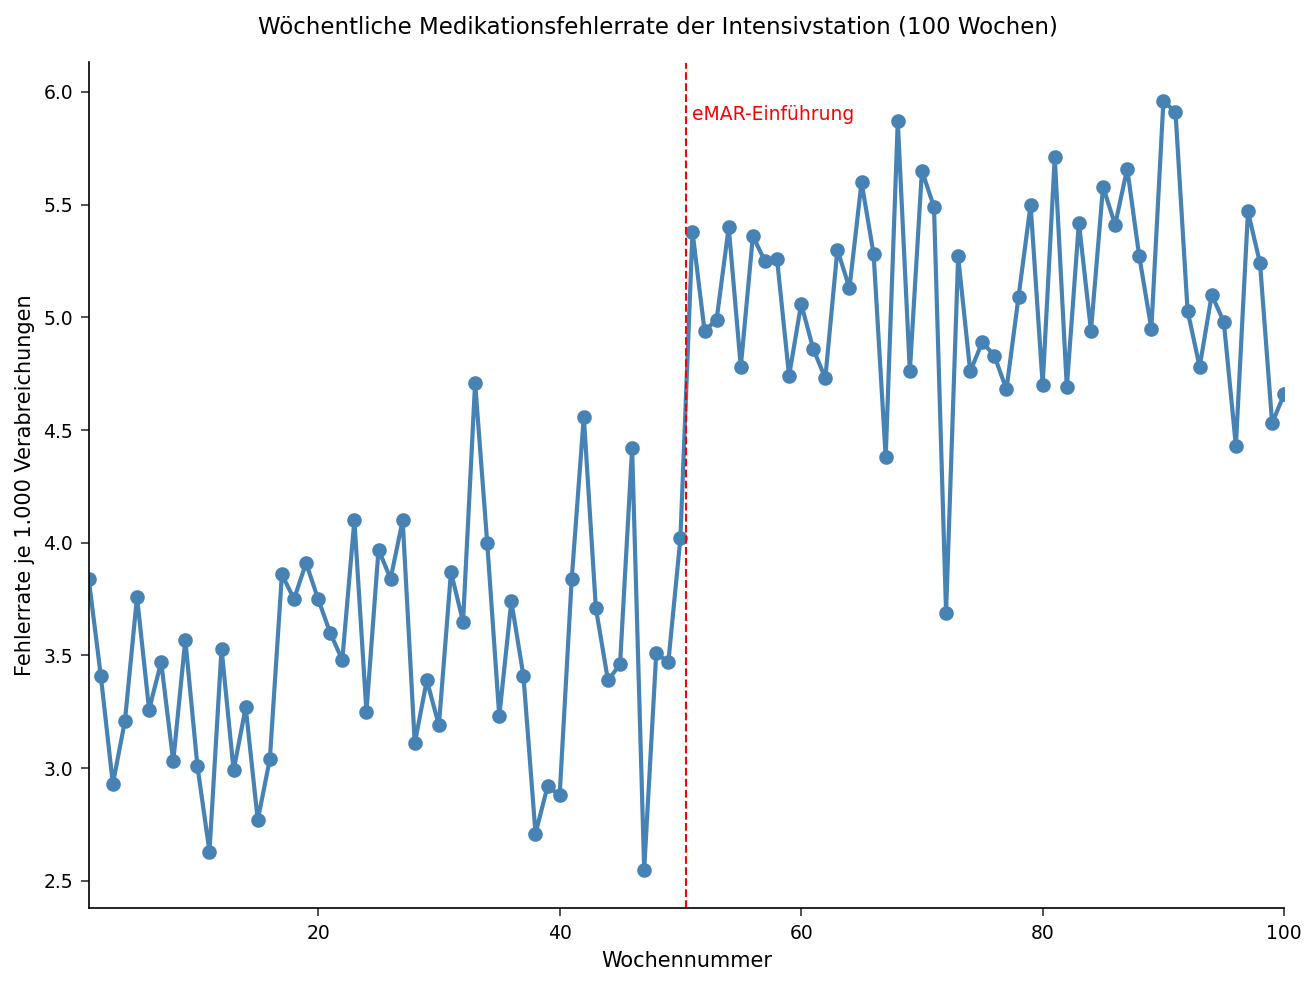

In [2]:
/* --------------------------------------------------------
   Fehlerrate vor und nach der eMAR-Einführung vergleichen
   und den wöchentlichen Trend darstellen.
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.icu_errors n mean std MIN MAX maxdec=2;
    KLASSE phase;
    VAR error_rate_per_1k error_count administrations;
    BEZEICHNUNG phase = 'Phase'
          error_rate_per_1k = 'Fehlerrate je 1.000'
          error_count = 'Fehleranzahl'
          administrations = 'Verabreichungen';
    TITEL 'ITS-Fehlerrate: Basislinie vs. Nach-eMAR';
AUSFÜHREN;

PROZEDUR SGPLOT DATEN=work.icu_errors;
    SERIES x=week_num y=error_rate_per_1k / MARKERS
           LINEATTRS=(color=steelblue thickness=2);
    REFLINE 50.5 / AXIS=x LINEATTRS=(color=red pattern=dash)
                   BEZEICHNUNG='eMAR-Einführung';
    XAXIS BEZEICHNUNG='Wochennummer';
    YAXIS BEZEICHNUNG='Fehlerrate je 1.000 Verabreichungen';
    TITEL 'Wöchentliche Medikationsfehlerrate der Intensivstation (100 Wochen)';
AUSFÜHREN;


---

In [3]:
/* --------------------------------------------------------
   Phase I: EWMA-Regelgrenzen aus der stabilen Basislinie vor
   der Migration (Wochen 1-50) festlegen. Diese fixen Grenzen
   werden zum Maßstab für den gesamten Überwachungszeitraum.
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.icu_errors(WO=(week_num <= 50)) NOPRINT;
    VAR error_rate_per_1k;
    AUSGABE out=work.baseline_stats mean=base_mean std=base_std;
AUSFÜHREN;

DATEN work.icu_limits;
    FESTLEGEN work.baseline_stats;
    LÄNGE _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* Mittellinie der Basislinie */
    _STDDEV_ = base_std;    /* Basis-Sigma (common-cause) */
    _LIMITN_ = 1;
    BEHALTEN _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=work.icu_limits noobs;
    TITEL 'Phase-I-Eingaben für Regelgrenzen (Basislinie Wochen 1-50)';
AUSFÜHREN;


                               Phase-I-Eingaben für Regelgrenzen (Basislinie Wochen 1-50)                               

            _VAR_  _SUBGRP_  _MEAN_      _STDDEV_  _LIMITN_
error_rate_per_1k  week_num  3.5014  0.4829036749         1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                               Phase-I-Eingaben für Regelgrenzen (Basislinie Wochen 1-50)                               


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/193924a5-19dc-4491-8170-5b1ab671610d/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


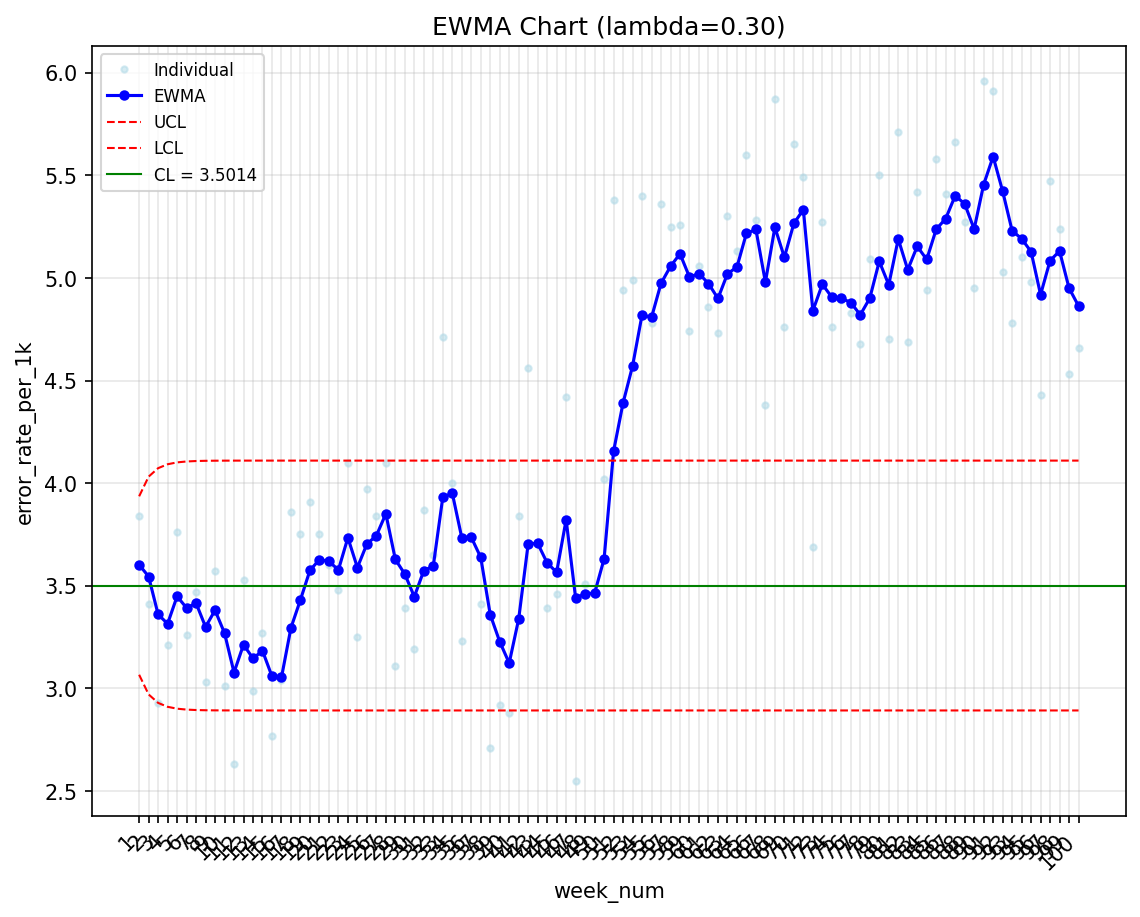

In [4]:
/* --------------------------------------------------------
   Phase II: die vollständige 100-Wochen-Reihe gegen die fixen
   Basislinien-Grenzen überwachen. Lambda=0,3 liefert eine
   reaktionsschnelle Erkennung für die Patientensicherheitsüberwachung.
   -------------------------------------------------------- */
PROZEDUR macontrol DATEN=work.icu_errors limits=work.icu_limits;
    ewmachart error_rate_per_1k * week_num /
        GEWICHT    = 0.3
        sigmas    = 3
        readlimits
        outtable  = work.icu_table;
    BEZEICHNUNG error_rate_per_1k =
          'Medikationsfehler je 1.000 Verabreichungen';
    TITEL 'EWMA-Karte: Medikationsfehlerrate der Intensivstation (Lambda=0,3)';
AUSFÜHREN;


---

In [5]:
/* --------------------------------------------------------
   Jede Woche identifizieren, deren EWMA-Wert die Basislinien-
   grenzen überschreitet, und melden, wann die Karte erstmals signalisiert.
   -------------------------------------------------------- */
DATEN work.signals;
    FESTLEGEN work.icu_table;
    WO _EXLIM_ ne ' ' UND _EXLIM_ ne '0';
AUSFÜHREN;

PROZEDUR SQL;
    AUSWÄHLEN count(*)        AS n_signals          BEZEICHNUNG='Signalwochen',
           MIN(week_num)    AS first_signal_week  BEZEICHNUNG='Erste Signalwoche',
           MAX(_EWMA_)      AS peak_ewma format=6.3 BEZEICHNUNG='Höchster EWMA-Wert'
    VON work.signals;
QUIT;

PROZEDUR DRUCKEN DATEN=work.signals(obs=8);
    VAR week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    BEZEICHNUNG week_num = 'Woche'
          error_rate_per_1k = 'Fehlerrate je 1.000'
          _EWMA_ = 'EWMA'
          _UCLE_ = 'Obere Regelgrenze'
          _EXLIM_ = 'Grenzüberschreitung';
    TITEL 'Erste außer Kontrolle geratene EWMA-Signale';
AUSFÜHREN;


                               Phase-I-Eingaben für Regelgrenzen (Basislinie Wochen 1-50)                               

Signalwochen  Erste Signalwoche   Höchster EWMA-Wert
------------  -----------------  -------------------
          50               51.0                5.591
                                      Erste außer Kontrolle geratene EWMA-Signale                                       

  Obs  Woche      EWMA  Obere Regelgrenze   Grenzüberschreitung
    1     51  4.155551            4.10998                     1
    2     52  4.390886            4.10998                     1
    3     53   4.57062            4.10998                     1
    4     54  4.819434            4.10998                     1
    5     55  4.807604            4.10998                     1
    6     56  4.973323            4.10998                     1
    7     57  5.056326            4.10998                     1
    8     58  5.117428            4.10998                     1

... 42 more observat


NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### Interpretation

Die zweiphasige EWMA-Analyse trennt gewöhnliche wöchentliche Schwankungen sauber von der realen Prozessänderung bei der eMAR-Einführung.

**Basislinie (Wochen 1-50).** PROC MEANS berichtet eine mittlere Basisfehlerrate von **3,50 je 1.000 Verabreichungen** (Standardabweichung 0,48) gegenüber einem Mittelwert nach der Migration von **5,11** (Standardabweichung 0,44) — eine anhaltende Aufwärtsverschiebung von etwa **1,6 Fehlern je 1.000**. Das Verabreichungsvolumen ist in beiden Phasen vergleichbar (795 gegenüber 790 pro Woche), sodass die Änderung die Fehler*rate* widerspiegelt und nicht eine Schwankung der Arbeitslast.

**Regelgrenzen.** Die Grenzen werden ausschließlich aus der Basislinie festgelegt: Mittellinie **3,5014**, Basis-Sigma **0,4829**. Mit Glättungsgewicht Lambda = 0,3 und 3-Sigma-Grenzen pendelt sich die obere EWMA-Grenze bei ihrem asymptotischen Wert von etwa **4,11** ein. Während der Wochen 1-50 bleibt die EWMA-Statistik durchgehend innerhalb dieser Grenzen — die Basislinie erzeugt **null Fehlalarme** und bestätigt damit, dass die Karte nicht übermäßig empfindlich ist.

**Erkennung.** Die Karte signalisiert außer Kontrolle in der **allerersten Woche nach der Einführung (Woche 51)**, in der der EWMA-Wert **4,156** erreicht, knapp über der Grenze von 4,11. Von diesem Punkt an steigt die Statistik stetig weiter und bleibt für den gesamten Zeitraum nach der Migration über der oberen Grenze: **alle 50 Wochen nach der Migration (51-100) signalisieren**, und der EWMA-Wert erreicht seinen Höchststand von **5,591** um Woche 91. Die Reaktionsfreudigkeit von Lambda = 0,3 bedeutet, dass die Verschlechterung sofort erkannt wird und nicht erst nach mehreren Wochen der Anhäufung.

**Maßnahme.** Eine anhaltende EWMA-Grenzüberschreitung, die in der Woche der eMAR-Einführung beginnt, ist ein starker Beleg dafür, dass das neue System — nicht der Zufall — den Anstieg verursacht hat. Das Patientensicherheitskomitee sollte Woche 51 als Wendepunkt behandeln, die in dieser Woche eingeführten eMAR-Medikationsbestell- und Override-Workflows prüfen und die Karte weiterhin gegen die ursprünglichen Basislinien-Grenzen laufen lassen, bis der EWMA-Wert wieder unter 4,11 fällt. Die exportierten Dateien `icu_ewma_signals.csv` (50 Signalwochen) und `icu_ewma_table.csv` liefern den dokumentierten SPC-Nachweispfad für die kontinuierliche Prüfbereitschaft der Joint Commission.

---

In [6]:
/* --------------------------------------------------------
   Die EWMA-Tabelle und Signalliste für die kontinuierliche
   Prüfbereitschaftsdokumentation der Joint Commission exportieren.
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.icu_table
    OUTFILE='icu_ewma_table.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;

PROZEDUR EXPORT DATEN=work.signals
    OUTFILE='icu_ewma_signals.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;



NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>